# Assignment 2: ECG Signal Classification

Authors:
Christian Mardini

## Imports

In [1]:
# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
warnings.filterwarnings("ignore")

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

# ECG-specific library
import wfdb

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

2026-02-18 20:45:52.363269: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
NumPy version: 2.4.2


## Load Metadata

In [3]:
# Set path to data
path = 'raw_data/'
sampling_rate = 100  # Use 100 Hz data

# Load main database
df = pd.read_csv(path + 'ptbxl_database.csv', index_col='ecg_id')
print(f"Database shape: {df.shape}")
print(f"Total ECG records: {len(df)}")

# Show first few rows
df.head()

Database shape: (21799, 27)
Total ECG records: 21799


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


## Explore Metadata

In [4]:
# Check columns
print("Columns in database:")
print(df.columns.tolist())
print()

# Check key columns
print("Sample of key columns:")
print(df[['age', 'sex', 'height', 'weight', 'scp_codes', 'strat_fold']].head())

Columns in database:
['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr']

Sample of key columns:
         age  sex  height  weight                                 scp_codes  \
ecg_id                                                                        
1       56.0    1     NaN    63.0  {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}   
2       19.0    0     NaN    70.0              {'NORM': 80.0, 'SBRAD': 0.0}   
3       37.0    1     NaN    69.0                {'NORM': 100.0, 'SR': 0.0}   
4       24.0    0     NaN    82.0                {'NORM': 100.0, 'SR': 0.0}   
5       19.0    1     NaN    70.0                {'NORM': 100.0, 'SR': 0

## Load Label Descriptions

In [5]:
# Load SCP (Standardized Communication Protocol) statements
agg_df = pd.read_csv(path + 'scp_statements.csv', index_col=0)

print(f"Label descriptions shape: {agg_df.shape}")
print()

# Show diagnostic classes
print("Diagnostic classes available:")
print(agg_df['diagnostic_class'].value_counts())
print()

# Show some examples
print("Example labels:")
agg_df[['description', 'diagnostic_class']].head(10)

Label descriptions shape: (71, 12)

Diagnostic classes available:
diagnostic_class
MI      14
STTC    13
CD      11
HYP      5
NORM     1
Name: count, dtype: int64

Example labels:


,description,diagnostic_class
NDT,non-diagnostic T abnormalities,STTC
NST_,non-specific ST changes,STTC
DIG,digitalis-effect,STTC
LNGQT,long QT-interval,STTC
NORM,normal ECG,NORM
IMI,inferior myocardial infarction,MI
ASMI,anteroseptal myocardial infarction,MI
LVH,left ventricular hypertrophy,HYP
LAFB,left anterior fascicular block,CD
ISC_,non-specific ischemic,STTC


## Parse SCP Codes

In [6]:
# Convert string representation of dict to actual dict
# scp_codes looks like: "{'NORM': 100.0, 'IMI': 50.0}"
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

print("Example scp_codes:")
print(df['scp_codes'].iloc[0])
print()

# Check how many labels per sample
df['num_labels'] = df['scp_codes'].apply(len)
print(f"Average labels per ECG: {df['num_labels'].mean():.2f}")
print(f"Max labels per ECG: {df['num_labels'].max()}")

Example scp_codes:
{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}

Average labels per ECG: 2.80
Max labels per ECG: 9


## Visualize Data Distribution

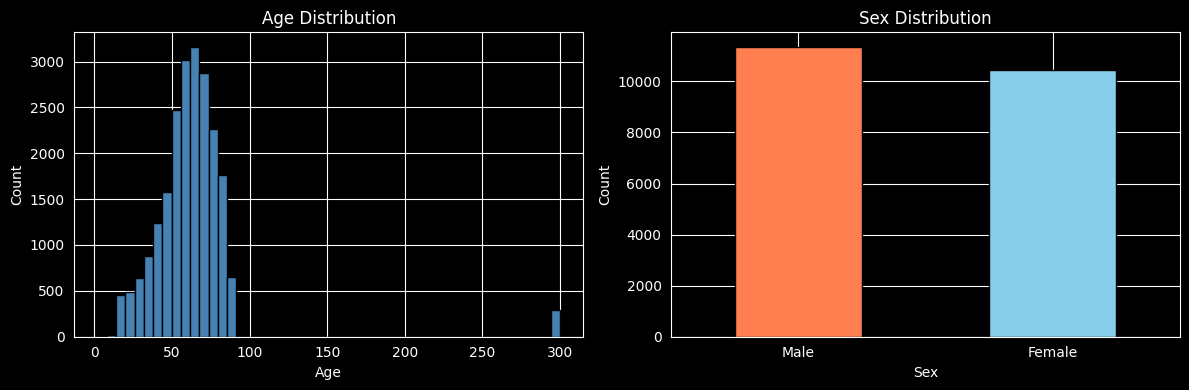

Male: 11354
Female: 10445


In [7]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['age'].dropna(), bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution')

# Sex distribution
df['sex'].value_counts().plot(kind='bar', ax=axes[1], color=['coral', 'skyblue'], edgecolor='black')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Count')
axes[1].set_title('Sex Distribution')
axes[1].set_xticklabels(['Male', 'Female'], rotation=0)

plt.tight_layout()
plt.show()

print(f"Male: {(df['sex']==0).sum()}")
print(f"Female: {(df['sex']==1).sum()}")

## Check Data Splits

In [8]:
# PTB-XL has predefined folds (1-10)
# Standard: fold 1-8 = train, fold 9 = val, fold 10 = test

print("Fold distribution:")
print(df['strat_fold'].value_counts().sort_index())
print()

# Calculate split sizes
train_size = len(df[df.strat_fold <= 8])
val_size = len(df[df.strat_fold == 9])
test_size = len(df[df.strat_fold == 10])

print(f"Train samples: {train_size} ({train_size/len(df)*100:.1f}%)")
print(f"Val samples: {val_size} ({val_size/len(df)*100:.1f}%)")
print(f"Test samples: {test_size} ({test_size/len(df)*100:.1f}%)")

Fold distribution:
strat_fold
1     2175
2     2181
3     2192
4     2174
5     2174
6     2173
7     2176
8     2173
9     2183
10    2198
Name: count, dtype: int64

Train samples: 17418 (79.9%)
Val samples: 2183 (10.0%)
Test samples: 2198 (10.1%)


## Load ONE ECG Signal (Test)

In [9]:
# Let's load one ECG to see how it looks
# Take the first record
sample_id = df.index[0]
filename = df.loc[sample_id, 'filename_lr']  # _lr = low resolution (100 Hz)

print(f"Loading ECG {sample_id}")
print(f"Filename: {filename}")

# Load signal
signal, meta = wfdb.rdsamp(path + filename)

print(f"\nSignal shape: {signal.shape}")
print(f"Signal length: {signal.shape[0]} samples")
print(f"Number of leads: {signal.shape[1]} leads")
print(f"Duration: {signal.shape[0]/sampling_rate} seconds")

Loading ECG 1
Filename: records100/00000/00001_lr

Signal shape: (1000, 12)
Signal length: 1000 samples
Number of leads: 12 leads
Duration: 10.0 seconds


## Visualize ECG Signal

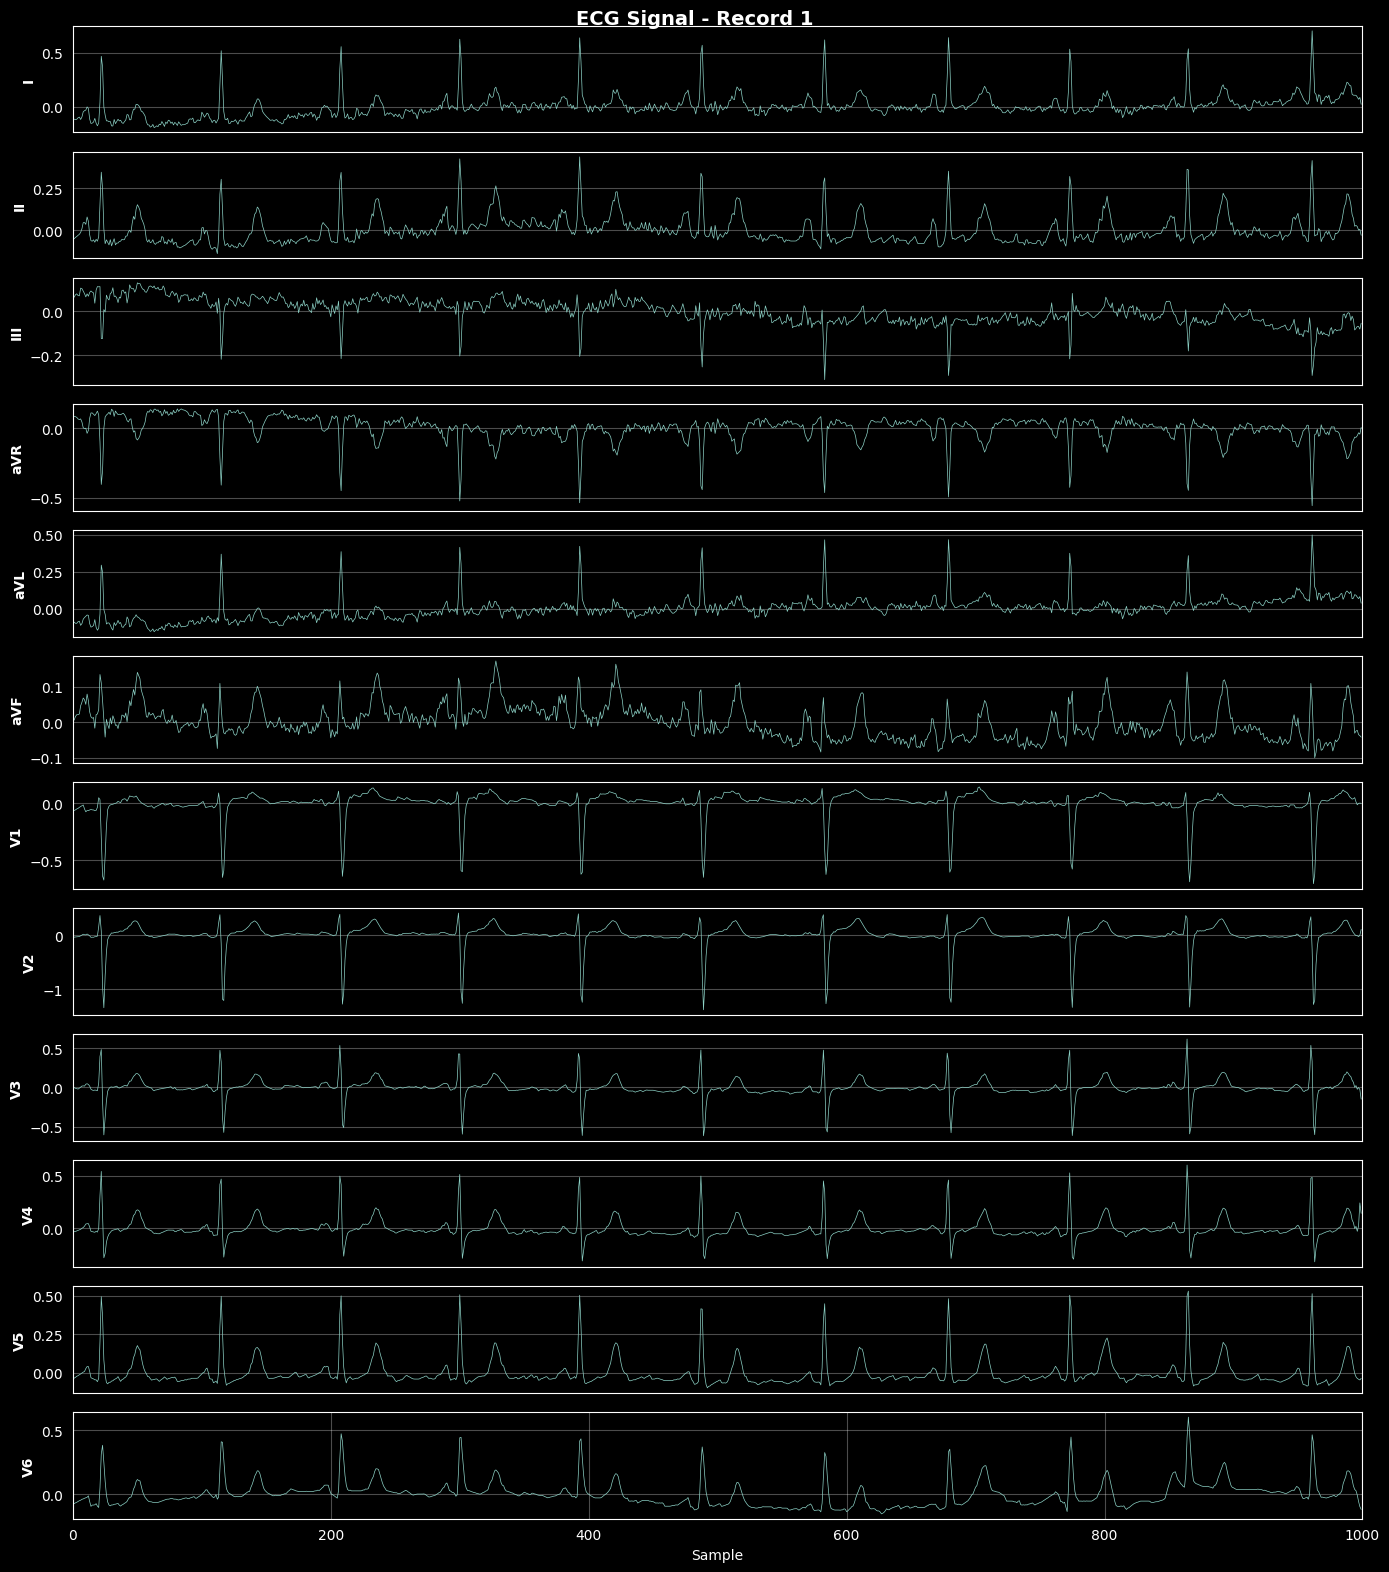

In [10]:
# Plot all 12 leads
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

fig, axes = plt.subplots(12, 1, figsize=(14, 16))

for i in range(12):
    axes[i].plot(signal[:, i], linewidth=0.5)
    axes[i].set_ylabel(lead_names[i], fontsize=10, fontweight='bold')
    axes[i].set_xlim([0, 1000])
    axes[i].grid(alpha=0.3)

    if i < 11:
        axes[i].set_xticks([])

axes[11].set_xlabel('Sample')
plt.suptitle(f'ECG Signal - Record {sample_id}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary: Step 1 - Data Loading

**Dataset:** PTB-XL 1.0.3
**Total records:** 21,837
**Sampling rate:** 100 Hz
**Signal shape:** (1000 samples, 12 leads)
**Duration:** 10 seconds per ECG

**Splits:**
- Train: folds 1-8 (~19,500 samples)
- Validation: fold 9 (~1,000 samples)
- Test: fold 10 (~1,000 samples)

**Labels:** Multi-label classification (one ECG can have multiple diagnoses)

**Next:** Extract diagnostic superclasses and prepare labels